<a href="https://colab.research.google.com/github/m1deey/Loan_pediction/blob/main/02_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
df=pd.read_csv('loan_approval_dataset.csv')
df.columns = df.columns.str.strip()

df["total_assets"] = (
    df["residential_assets_value"] +
    df["commercial_assets_value"] +
    df["luxury_assets_value"] +
    df["bank_asset_value"]
)

df = df.drop(columns=[
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
    "loan_id"
])
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,total_assets
0,2,Graduate,No,9600000,29900000,12,778,Approved,50700000
1,0,Not Graduate,Yes,4100000,12200000,8,417,Rejected,17000000
2,3,Graduate,No,9100000,29700000,20,506,Rejected,57700000
3,3,Graduate,No,8200000,30700000,8,467,Rejected,52700000
4,5,Not Graduate,Yes,9800000,24200000,20,382,Rejected,55000000


#feature encoding

In [13]:
df["loan_status"]=df["loan_status"].str.strip().map({"Approved":1,"Rejected":0})
df["self_employed"]=df["self_employed"].str.strip().map({"Yes":1,"No":0})
df["education"]=df["education"].str.strip().map({"Graduate":1,"Not Graduate":0})
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,total_assets
0,2,1,0,9600000,29900000,12,778,1,50700000
1,0,0,1,4100000,12200000,8,417,0,17000000
2,3,1,0,9100000,29700000,20,506,0,57700000
3,3,1,0,8200000,30700000,8,467,0,52700000
4,5,0,1,9800000,24200000,20,382,0,55000000


In [16]:
X=df.drop("loan_status",axis=1)
y=df["loan_status"]

#building predictions model

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.61      0.69       318
           1       0.80      0.91      0.85       536

    accuracy                           0.80       854
   macro avg       0.80      0.76      0.77       854
weighted avg       0.80      0.80      0.79       854



We get 80% accuracy from the Logistic Regression now we test it

In [22]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,0,0


#10/10 the model get from the first 10 row
Let's try other models

In [39]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred_dt = model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9754098360655737
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       318
           1       0.97      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854

Training Accuracy: 1.0
Testing Accuracy: 0.9847775175644028


In [40]:
comparison_dt = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_dt
})

comparison_dt.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,0,0


We get 98% accuracy from Decision tree and more 10/10 let's vasuels it

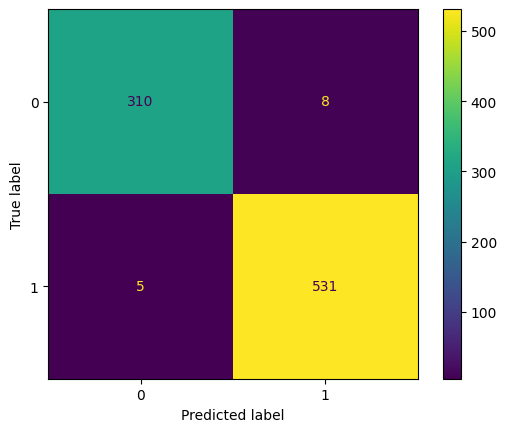

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.show()

The model get 310 rejected and 5 rejected said it's aproved and he get 531 aproved and 8 aproved said it is rejected

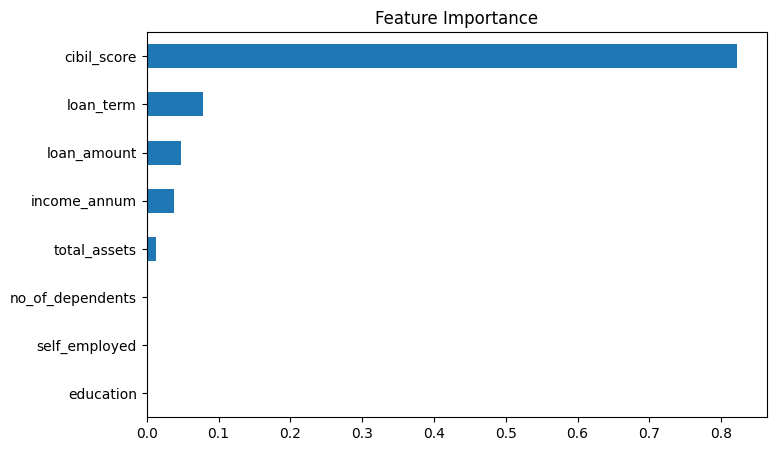

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Feature Importance")
plt.show()

We see from the graph that cibil_score is what the Decision tree relied on thr most

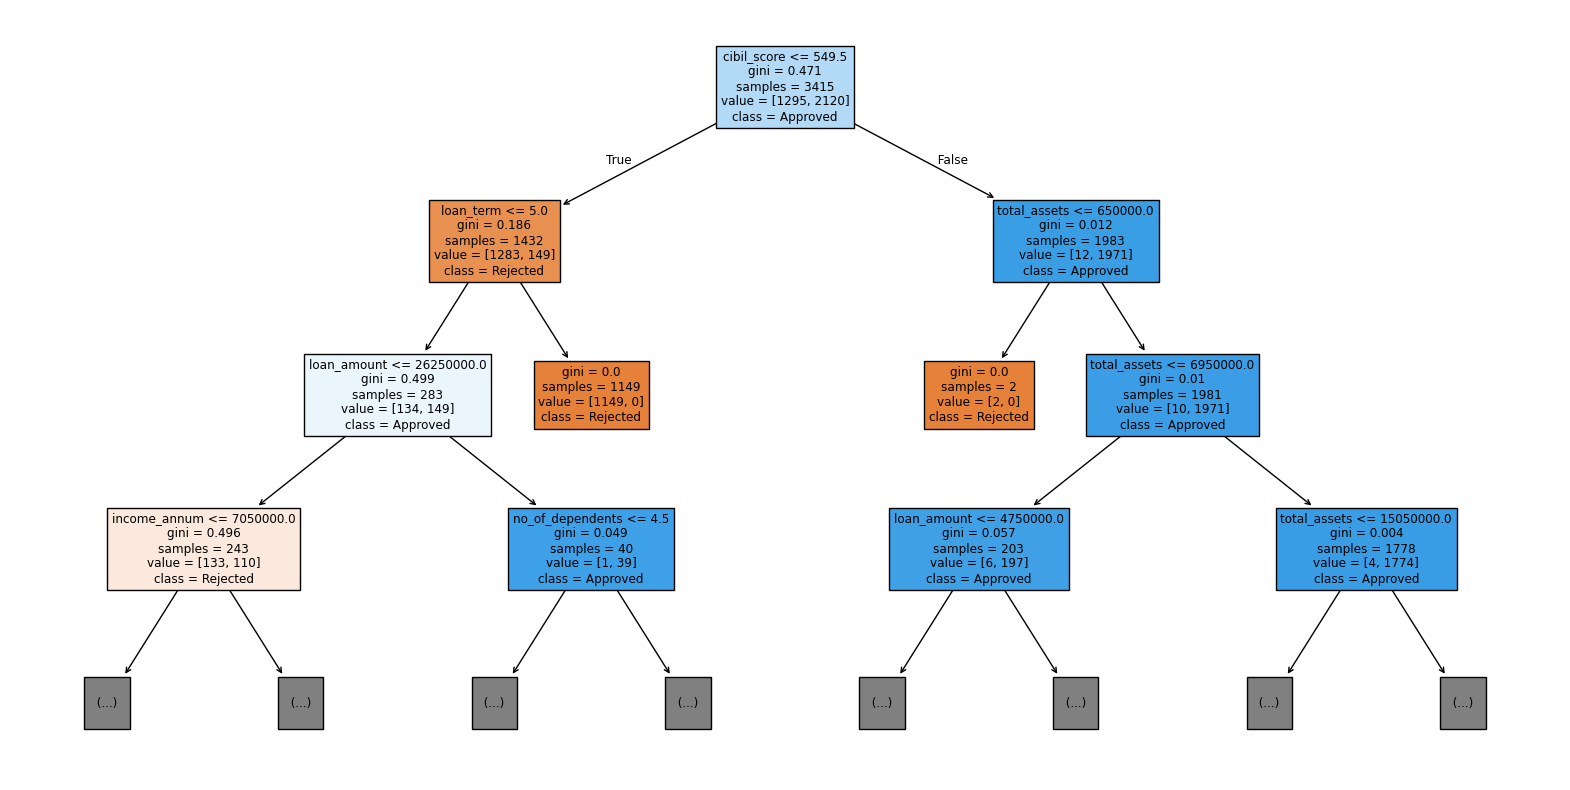

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    max_depth=3
)
plt.show()

Let's check Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)
y_pred_rf=model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9754098360655737
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       318
           1       0.97      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854

Training Accuracy: 1.0
Testing Accuracy: 0.9754098360655737


In [44]:
comparison_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

comparison_rf.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,0,0


Let's compare between the models

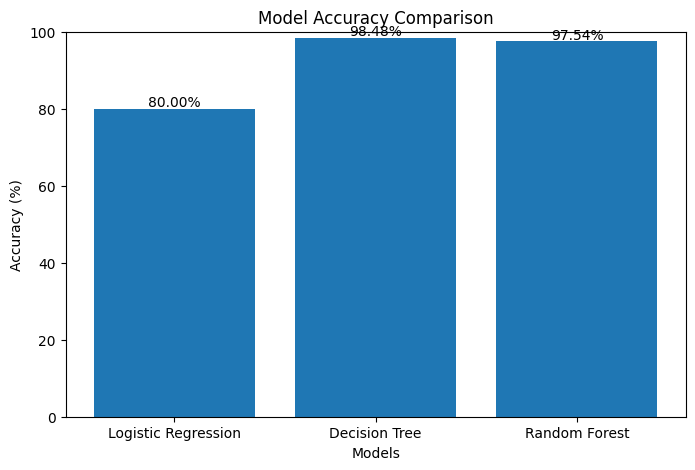

In [37]:


models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [80.00, 98.48, 97.54]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha="center")

plt.show()

#Final Conclusion
In this project, I built a machine learning model to predict whether a loan application would be approved or rejected.
I started by cleaning the dataset, handling the features, creating a new feature (total_assets), and encoding the categorical variables. Then, I explored the data using visualizations to understand the relationships between the features and the target variable.
After preprocessing, I trained and compared three machine learning models:
Logistic Regression — 80.00% accuracy
Decision Tree — 98.48% accuracy
Random Forest — 97.54% accuracy
The Decision Tree achieved the highest accuracy on the test set, while the Random Forest produced very similar performance. Logistic Regression served as a good baseline but was less accurate than the tree-based models.
This project gave me practical experience with the complete machine learning workflow, including data preprocessing, exploratory data analysis, feature engineering, model training, evaluation, and comparison.